In [1]:
import numpy as np
import matplotlib.pyplot as plt

from cifar10_data_preprocessing import *

In [2]:
data_dir = 'cifar-10-batches-py'

# Load cifar-10 dataset.
train_data, train_labels, test_data, test_labels, label_names = load_data(data_dir)

# Shuffle the train_data and divide into train_data and dev_data.
# num_dev indicates the number of image data in dev set.
dev_data, dev_labels, train_data, train_labels = split_dataset(train_data, train_labels, num_dev = 5000)

# Check the shape of train/dev/test data and number of classes.
print("Train data: ", train_data.shape)
print("Train labels: ", train_labels.shape)
print("Dev data: ", dev_data.shape)
print("Dev labels: ", dev_labels.shape)
print("Test data: ", test_data.shape)
print("Test labels: ", test_labels.shape)
print('Number of classes:', label_names.shape[0])

Train data:  (45000, 32, 32, 3)
Train labels:  (45000,)
Dev data:  (5000, 32, 32, 3)
Dev labels:  (5000,)
Test data:  (10000, 32, 32, 3)
Test labels:  (10000,)
Number of classes: 10


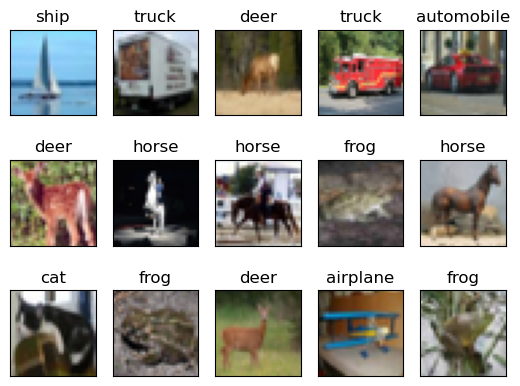

In [3]:
# Don't forget that the label_names and filesnames are in binary and need conversion if used.
classes = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])

# Display some random training images in a 3x5 grid
fig, ax = plt.subplots(3, 5)
for m in range(3):
    for n in range(5):
        idx = np.random.randint(0, train_data.shape[0])
        ax[m, n].set_title(classes[train_labels[idx]]) # display label
        ax[m, n].imshow(train_data[idx]) # display image data
        ax[m, n].get_xaxis().set_visible(False)
        ax[m, n].get_yaxis().set_visible(False)
plt.show()

In [4]:
# Convert label of each image data into one-hot vector(y). 
# Its length is the same as the number of classes.
y_train = one_hot_encoding(train_labels, classes)
y_dev = one_hot_encoding(dev_labels, classes)
y_test = one_hot_encoding(test_labels, classes)

print(y_train[0])
print(y_train.shape)


[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
(45000, 10)


In [5]:
# Normalize pixel values of input image from [0, 255] range to [0, 1] range.
x_train = normalize_image(train_data)
x_dev = normalize_image(dev_data)
x_test = normalize_image(test_data)

print(train_data[0]) # before normalization
print(x_train[0]) # after normalization

[[[ 55  53   1]
  [ 61  61   0]
  [ 65  65   1]
  ...
  [ 83  93   3]
  [ 86  94  10]
  [ 87  94  20]]

 [[ 61  59   0]
  [ 66  66   0]
  [ 68  68   1]
  ...
  [ 89 100   7]
  [ 94 103  23]
  [101 107  47]]

 [[ 75  73   4]
  [ 78  77   3]
  [ 77  75   2]
  ...
  [103 112  50]
  [134 140  95]
  [182 184 159]]

 ...

 [[ 40  69   9]
  [ 44  69   8]
  [ 49  73  10]
  ...
  [105 119  51]
  [113 120  56]
  [112 119  58]]

 [[ 44  63  18]
  [ 43  59  14]
  [ 48  62  15]
  ...
  [155 145 121]
  [164 146 129]
  [164 146 134]]

 [[ 66  65  44]
  [ 71  68  45]
  [ 73  68  44]
  ...
  [187 173 164]
  [189 169 163]
  [174 153 149]]]
[[[0.15966387 0.15833333 0.00392157]
  [0.18487395 0.19166667 0.        ]
  [0.20168067 0.20833333 0.00392157]
  ...
  [0.27731092 0.325      0.01176471]
  [0.28991597 0.32916667 0.03921569]
  [0.29411765 0.32916667 0.07843137]]

 [[0.18487395 0.18333333 0.        ]
  [0.20588235 0.2125     0.        ]
  [0.21428571 0.22083333 0.00392157]
  ...
  [0.30252101 0.3541666